# Machine Learning

There are some tasks where a machine can perform better eg: calculations, and some task a human can perform better than a machine eg: riding or conversations. 

**Machine Learning** is a domain where we teach machine to learn from data and find patterns on their own.

Although Machine Learning is a broader term which encompasses topics like deep learning, we this discuss topics from basics to advanced level.

## Types of Machine Learning

1. Supervised - We give labelled data ->  **Classification**, **Regression** 
2. Unsupervised - We give unlabelled data ->  **Clustering**, **Association**

### Linear Regression 

We try to fit a line through all the data points, ensuring that the line will have the least average error. Using the line as a reference we predict the value for any given input.

Lets look at how it works with example

#### Using Single variable 

Task: Predict Income based on year <br>
use the csv file: canada_per_capita_income, to train a model and prdict income

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


In [185]:
# load the file to pandas data frame

df = pd.read_csv("canada_per_capita_income.csv")
df.columns = ["year", "income"]

df.head()

,year,income
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


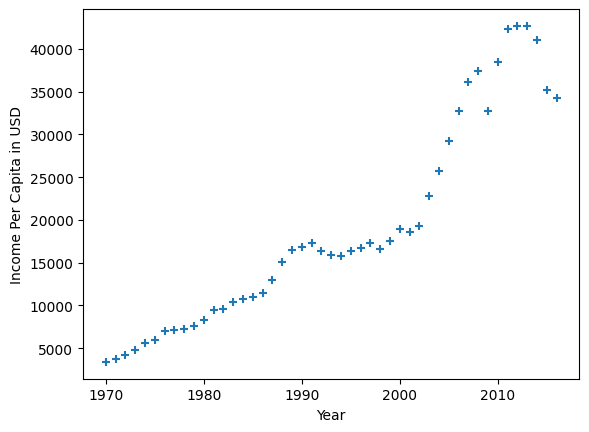

In [186]:
%matplotlib inline
plt.xlabel("Year")
plt.ylabel("Income Per Capita in USD")
plt.scatter( df.year, df.income,  marker="+")

Let us now fit a line using Linear Regression

In [187]:
reg = linear_model.LinearRegression()
reg.fit(df[['year']], df.income)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[828.47]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.632e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Let us now predict income for any year

In [188]:
reg.predict([[2016]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([37974.83379353])

Let us see the line using plot

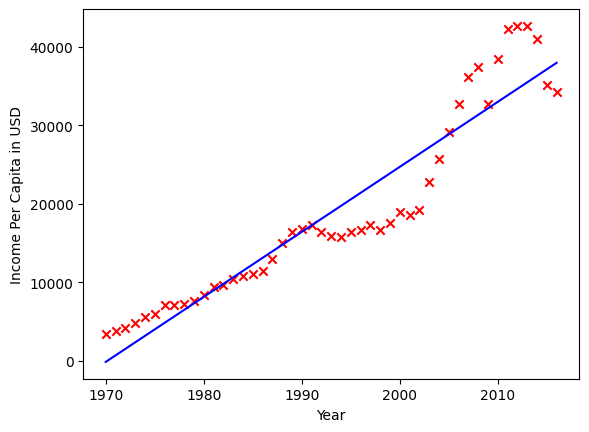

In [189]:
%matplotlib inline

plt.xlabel("Year")
plt.ylabel("Income Per Capita in USD")
plt.scatter( df.year, df.income, color="red", marker="x")
plt.plot(df.year, reg.predict(df[['year']]), color="blue")



#### Multiple Variable or Multivariate Regression

In single variable model, we only had one feature ,i.e year, which is also called as independent variable. 
Now we will look at an example of mutiple vairables.
The file hiring.csv contains some data

In [190]:
df = pd.read_csv("hiring.csv")
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


Take a look at the data, we have 3 features, independent vaiables and 1 dependent variable(salary). Lets build a model that will predict the salary based on this little data.

**Step 1.** Data Preprocessing - we first need to clean the data -> handle missing data. Also our model takes only numericals as input hence we will have to convert the experience from string to integer.

In [191]:
#fill all N/As with zero
df.experience = df.experience.fillna("zero")    

In [192]:
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [193]:
# we can use this library to converth str to int
from word2number import w2n
# eg 
print(w2n.word_to_num("twenty"))


20


In [194]:
df.experience = df.experience.apply(w2n.word_to_num)


In [195]:
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000


If we notice, the columns names are too long for use to type - lazy - let us rename them

In [196]:
df.columns = ["experience", "test_score", "interview_score", "salary" ]
df.head(10)

,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


The experience columns has a NaN val - lets us fix that

In [197]:
# lets fill that NaN with median values
import math

median_test_score = math.floor(df["test_score"].median())
median_test_score

8

In [198]:
df.test_score = df.test_score.fillna(median_test_score)
df.head(10)

,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


Now **Step 1** is Complete <br>
Let us now build a model

In [199]:
reg = linear_model.LinearRegression()
reg.fit(df[["experience", "test_score", "interview_score"]], df.salary)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[2812.95,1845.71,2205.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['experience','test_score','interview_score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.774e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


Now we can predict the values.

lets predict salary of two cases - <br>
2 yr experience, 9 test score, 6 interview score

12 yr experience, 10 test score, 10 interview score

In [200]:
reg.predict([[2, 9, 6]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53205.96797671])

In [201]:
reg.predict([[12, 10, 10]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92002.18340611])

**How does the model find the best fit line?**

The simplest explanation is using the slope of the line `y = mX = b`, where m and b are independent variable and X is the value which we will predict, we find a value for Slope and compare the distances of each point v/s the line and square them (to account for negatives and to make things more precise) this is called squared error, after this we divide this value by the total number of points which we compared **n** -> this is know as **Mean Squared Error** and this is one the cost function -> we try to minimze the cost function, basically - the lower the cost the better the fit.

**How do we find the lowest cost for this?** using Graient Descent(Learn more about it personally). Here we will only implement the function.

In [261]:
import numpy as np
import pandas as pd

def gradient_descent(x, y):
    n = len(x)
    iterations = 1000
    learning_rate = 0.1  # Fast learning rate works now!
    m_curr = b_curr = 0.0
    old_cost = float('inf')

    # Feature Scaling (Z-score normalization)
    x_scaled = (x - np.mean(x)) / np.std(x)
    y_scaled = (y - np.mean(y)) / np.std(y)

    for i in range(iterations):
        y_predicted = m_curr * x_scaled + b_curr
        cost = np.mean((y_scaled - y_predicted) ** 2)
        
        md = -(2/n) * np.sum(x_scaled * (y_scaled - y_predicted))
        bd = -(2/n) * np.sum(y_scaled - y_predicted)
        
        m_curr -= learning_rate * md
        b_curr -= learning_rate * bd
        
        if abs(old_cost - cost) < 1e-7:
            print(f"Converged smoothly at iteration {i}!")
            print(f"Scaled Parameters -> m: {m_curr:.4f}, b: {b_curr:.4f}, cost: {cost:.6f}")
            break
            
        old_cost = cost

df = pd.read_csv("test_scores.csv")
x = df["math"].to_numpy()
y = df["cs"].to_numpy()

gradient_descent(x, y)

Converged smoothly at iteration 35!
Scaled Parameters -> m: 0.9479, b: -0.0000, cost: 0.100944
